# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

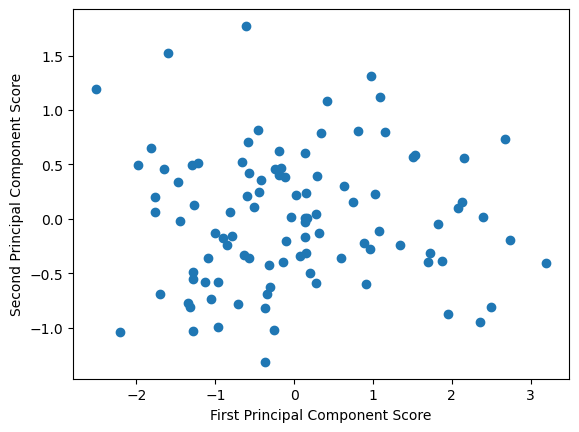

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

Answer: This NBA dataset was found by one of my teammates during first semester. I will perform the above tasks on this dataset

In [5]:
import seaborn as sns

In [ ]:
# Load the dataset
file_path = "./players.csv"
df = pd.read_csv(file_path)
df.head()

,index,_id,birthDate,birthPlace,career_AST,career_FG%,career_FG3%,career_FT%,career_G,career_PER,...,draft_pick,draft_round,draft_team,draft_year,height,highSchool,name,position,shoots,weight
0,0,abdelal01,"June 24, 1968","Cairo, Egypt",0.3,50.2,0.0,70.1,256,13.0,...,25th overall,1st round,Portland Trail Blazers,1990,6-10,"Bloomfield in Bloomfield, New Jersey",Alaa Abdelnaby,Power Forward,Right,240lb
1,1,abdulza01,"April 7, 1946","Brooklyn, New York",1.2,42.8,NaN,72.8,505,15.1,...,5th overall,1st round,Cincinnati Royals,1968,6-9,"John Jay in Brooklyn, New York",Zaid Abdul-Aziz,Power Forward and Center,Right,235lb
2,2,abdulka01,"April 16, 1947","New York, New York",3.6,55.9,5.6,72.1,1560,24.6,...,1st overall,1st round,Milwaukee Bucks,1969,7-2,"Power Memorial in New York, New York",Kareem Abdul-Jabbar,Center,Right,225lb
3,3,abdulma02,"March 9, 1969","Gulfport, Mississippi",3.5,44.2,35.4,90.5,586,15.4,...,3rd overall,1st round,Denver Nuggets,1990,6-1,"Gulfport in Gulfport, Mississippi",Mahmoud Abdul-Rauf,Point Guard,Right,162lb
4,4,abdulta01,"November 3, 1974","Maisons Alfort, France",1.1,41.7,23.7,70.3,236,11.4,...,11th overall,1st round,Sacramento Kings,1997,6-6,"Lycee Aristide Briand in Evreux, France",Tariq Abdul-Wahad,Shooting Guard,Right,223lb


In [34]:
# Convert height to inches
df['height_in'] = df['height'].str.split('-').apply(lambda x: int(x[0]) * 12 + int(x[1]))


# df['weight_lb'] = df['weight_lb'].fillna(0).astype(int)  # or use df['weight_lb'].dropna() later

# Convert weight to numeric
df['weight_lb'] = pd.to_numeric(df['weight'].str.replace('lb', '', regex=False), errors='coerce')


# Convert birthDate to datetime
df['birthDate'] = pd.to_datetime(df['birthDate'], errors='coerce')

# Ensure draft_year is numeric
df['draft_year'] = pd.to_numeric(df['draft_year'], errors='coerce')

# Calculate draft age
df['age_at_draft'] = df.apply(lambda row: row['draft_year'] - row['birthDate'].year 
                              if pd.notnull(row['birthDate']) and pd.notnull(row['draft_year']) 
                              else None, axis=1)

# Optional: Adjust age if birth month/day comes after typical draft month (June)
df['age_at_draft_adjusted'] = df.apply(
    lambda row: row['age_at_draft'] - 1 
    if pd.notnull(row['birthDate']) and pd.notnull(row['draft_year']) and row['birthDate'].month > 6 
    else row['age_at_draft'], axis=1)

# View result
print(df[['name', 'birthDate', 'draft_year', 'age_at_draft', 'age_at_draft_adjusted']])

# Preview
print(df[['birthDate', 'height_in', 'weight_lb', 'age']])

                     name  birthDate  draft_year  age_at_draft  \
0          Alaa Abdelnaby 1968-06-24      1990.0          22.0   
1         Zaid Abdul-Aziz 1946-04-07      1968.0          22.0   
2     Kareem Abdul-Jabbar 1947-04-16      1969.0          22.0   
3      Mahmoud Abdul-Rauf 1969-03-09      1990.0          21.0   
4       Tariq Abdul-Wahad 1974-11-03      1997.0          23.0   
...                   ...        ...         ...           ...   
4680           Ante Zizic 1997-01-04      2016.0          19.0   
4681             Jim Zoet 1953-12-20         NaN           NaN   
4682            Bill Zopf 1948-06-07      1970.0          22.0   
4683          Ivica Zubac 1997-03-18      2016.0          19.0   
4684           Matt Zunic 1919-12-19         NaN           NaN   

      age_at_draft_adjusted  
0                      22.0  
1                      22.0  
2                      22.0  
3                      21.0  
4                      22.0  
...                     ...

Here are some types of analysis you can do:
Draw heatmaps.

<span style="color:green">Answer</span>

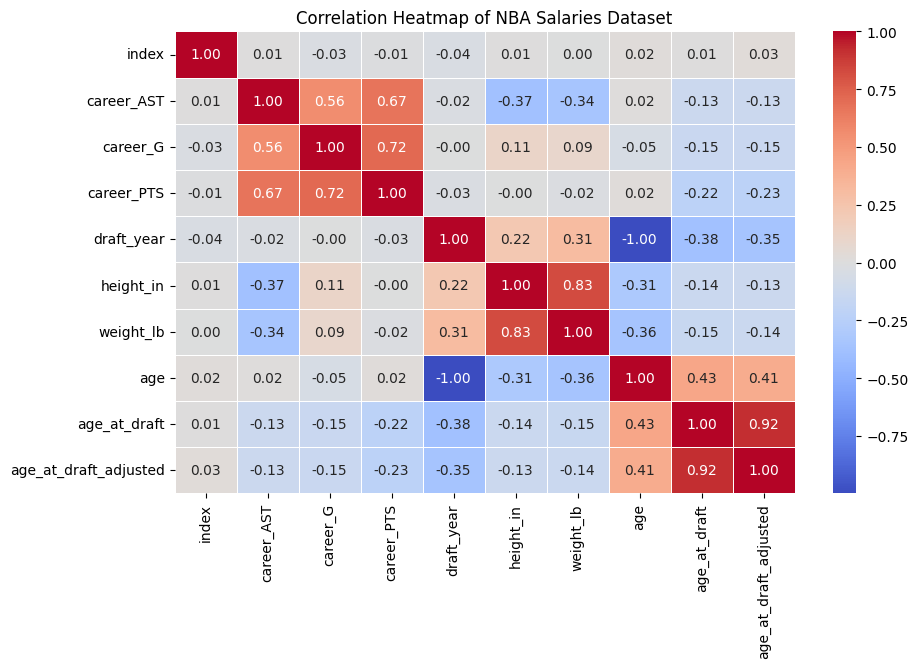

In [35]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of NBA Salaries Dataset")
plt.show()

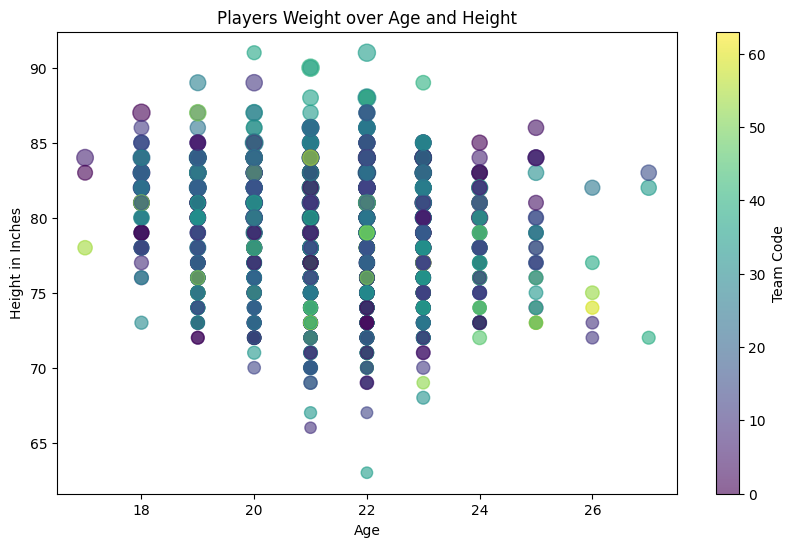

In [42]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['age_at_draft_adjusted'],
    df['height_in'],
    s=df['weight_lb'] / 2  ,  # scale bubble size
    c=pd.factorize(df['draft_team'])[0],  # assign color by team
    alpha=0.6,
    cmap='viridis'
)

plt.xlabel('Age')
plt.ylabel('Height in Inches')
plt.title('Players Weight over Age and Height')
plt.colorbar(label='Team Code')
plt.show()

In [52]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

numeric_df = df.select_dtypes(include='number')

# Fill values in the numeric columns 
fill_values = {
    'draft_year': numeric_df['draft_year'].mode().iloc[0],
    'age_at_draft': numeric_df['age_at_draft'].mode().iloc[0],
    'weight_lb': numeric_df['weight_lb'].mode().iloc[0],
    'height_in': numeric_df['height_in'].mode().iloc[0],
    'age_at_draft_adjusted': numeric_df['age_at_draft_adjusted'].mode().iloc[0]
}

# Fill NaN values for the columns specified
numeric_df.fillna(fill_values, inplace=True)

df_final=numeric_df[['draft_year','age_at_draft','weight_lb','height_in','age_at_draft_adjusted']]

df_final

,draft_year,age_at_draft,weight_lb,height_in,age_at_draft_adjusted
0,1990.0,22.0,240.0,82,22.0
1,1968.0,22.0,235.0,81,22.0
2,1969.0,22.0,225.0,86,22.0
3,1990.0,21.0,162.0,73,21.0
4,1997.0,23.0,223.0,78,22.0
...,...,...,...,...,...
4680,2016.0,19.0,254.0,83,19.0
4681,1968.0,22.0,240.0,85,22.0
4682,1970.0,22.0,170.0,73,22.0
4683,2016.0,19.0,240.0,85,19.0


In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_final)

# Perform PCA
pca = PCA()
pca.fit(df_scaled)

components = pd.DataFrame(pca.components_, columns=df_final.columns, index=['PC1', 'PC2', 'PC3','PC4','PC5'])

# Display the component vectors
print("Component Vectors:")
print(components)

# Explained variance ratio for each component
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained variance ratio for each component: {explained_variance_ratio}")

# Cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
print(f"Cumulative explained variance: {cumulative_explained_variance}")

Component Vectors:
     draft_year  age_at_draft  weight_lb  height_in  age_at_draft_adjusted
PC1   -0.414881      0.482248  -0.415500  -0.408077               0.506106
PC2   -0.032156      0.454142   0.547417   0.551322               0.434857
PC3    0.906094      0.290349  -0.147623  -0.190588               0.191244
PC4   -0.016600     -0.129858   0.700000  -0.690222               0.128279
PC5    0.074544     -0.678252  -0.126107   0.129565               0.708327
Explained variance ratio for each component: [0.4844437  0.3191059  0.14149203 0.03540055 0.01955781]
Cumulative explained variance: [0.4844437  0.8035496  0.94504163 0.98044219 1.        ]


In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [56]:
X=df_final.drop('weight_lb',axis='columns')
y=df_final['weight_lb']

LR_model=LinearRegression()
LR_model.fit(X,y)

y_pred=LR_model.predict(X)

df_predict = df_final.copy()  # Copy the original dataframe to avoid modifying it
df_predict['predicted_weight'] = y_pred  # Add the predicted values as a new column

mse_weight = mean_squared_error(y, y_pred)
rmse_weight= np.sqrt(mse_weight)

# Display the new dataframe
print(f'Predicted Weight in LB is:\n{df_predict}')
print(f'Mean Squared error of weight in LB prediction is :\n{mse_weight}')
print(f'\nSquare root of Weight in LB prediction is :\n{rmse_weight}')

Predicted Weight in LB is:
      draft_year  age_at_draft  weight_lb  height_in  age_at_draft_adjusted  \
0         1990.0          22.0      240.0         82                   22.0   
1         1968.0          22.0      235.0         81                   22.0   
2         1969.0          22.0      225.0         86                   22.0   
3         1990.0          21.0      162.0         73                   21.0   
4         1997.0          23.0      223.0         78                   22.0   
...          ...           ...        ...        ...                    ...   
4680      2016.0          19.0      254.0         83                   19.0   
4681      1968.0          22.0      240.0         85                   22.0   
4682      1970.0          22.0      170.0         73                   22.0   
4683      2016.0          19.0      240.0         85                   19.0   
4684      1968.0          22.0      195.0         75                   22.0   

      predicted_weight  

In [58]:
X=df_final.drop('height_in',axis='columns')
y=df_final['height_in']

LR_model=LinearRegression()
LR_model.fit(X,y)

y_pred=LR_model.predict(X)

df_predict = df_final.copy()  # Copy the original dataframe to avoid modifying it
df_predict['predicted_height'] = y_pred  # Add the predicted values as a new column

mse_height = mean_squared_error(y, y_pred)
rmse_height= np.sqrt(mse_height)

# Display the new dataframe
print(f'Predicted Hieght in Inches is:\n{df_predict}')
print(f'Mean Squared error of Hieght in Inches prediction is :\n{mse_height}')
print(f'\nSquare root of Hieght in Inches prediction is :\n{rmse_height}')

Predicted Hieght in Inches is:
      draft_year  age_at_draft  weight_lb  height_in  age_at_draft_adjusted  \
0         1990.0          22.0      240.0         82                   22.0   
1         1968.0          22.0      235.0         81                   22.0   
2         1969.0          22.0      225.0         86                   22.0   
3         1990.0          21.0      162.0         73                   21.0   
4         1997.0          23.0      223.0         78                   22.0   
...          ...           ...        ...        ...                    ...   
4680      2016.0          19.0      254.0         83                   19.0   
4681      1968.0          22.0      240.0         85                   22.0   
4682      1970.0          22.0      170.0         73                   22.0   
4683      2016.0          19.0      240.0         85                   19.0   
4684      1968.0          22.0      195.0         75                   22.0   

      predicted_heig

In [59]:
X=df_final.drop('age_at_draft',axis='columns')
y=df_final['age_at_draft']

LR_model=LinearRegression()
LR_model.fit(X,y)

y_pred=LR_model.predict(X)

df_predict = df_final.copy()  # Copy the original dataframe to avoid modifying it
df_predict['predicted_age'] = y_pred  # Add the predicted values as a new column

mse_age = mean_squared_error(y, y_pred)
rmse_age= np.sqrt(mse_age)

# Display the new dataframe
print(f'Predicted age at draft is:\n{df_predict}')
print(f'Mean Squared error of age_at_draft prediction is :\n{mse_age}')
print(f'\nSquare root of age_at_draft prediction is :\n{rmse_age}')

Predicted age at draft is:
      draft_year  age_at_draft  weight_lb  height_in  age_at_draft_adjusted  \
0         1990.0          22.0      240.0         82                   22.0   
1         1968.0          22.0      235.0         81                   22.0   
2         1969.0          22.0      225.0         86                   22.0   
3         1990.0          21.0      162.0         73                   21.0   
4         1997.0          23.0      223.0         78                   22.0   
...          ...           ...        ...        ...                    ...   
4680      2016.0          19.0      254.0         83                   19.0   
4681      1968.0          22.0      240.0         85                   22.0   
4682      1970.0          22.0      170.0         73                   22.0   
4683      2016.0          19.0      240.0         85                   19.0   
4684      1968.0          22.0      195.0         75                   22.0   

      predicted_age  
0 

The age from height and weight has the mininum error, therefore, sounds like this is the best model.

<Axes: >

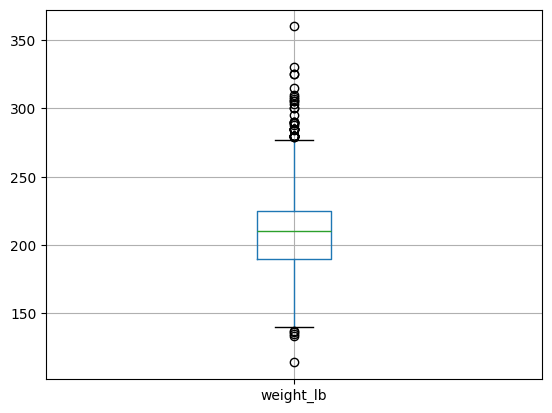

In [64]:
df_final.boxplot(column='weight_lb')

Weight outliers are not irrational numbers.

<Axes: >

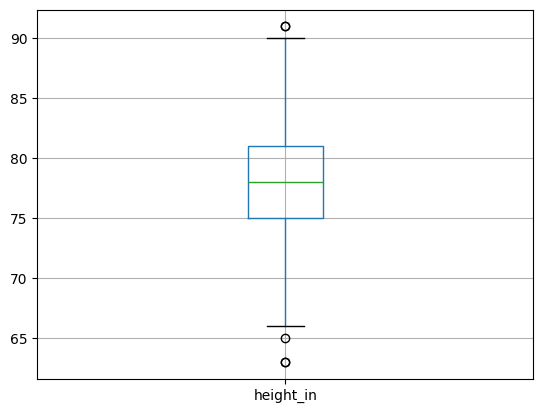

In [65]:
df_final.boxplot(column='height_in')

height outliers are very less and not irrational either.

<Axes: >

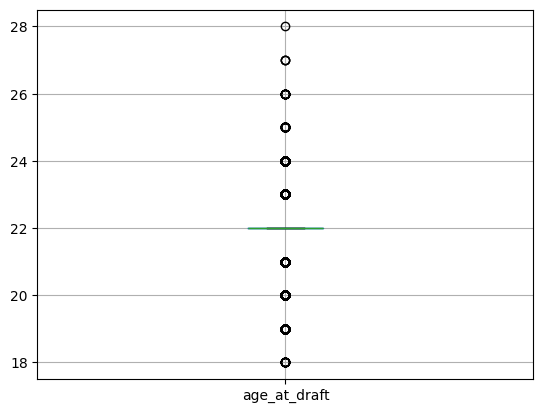

In [69]:
df_final.boxplot(column='age_at_draft')

age at draft outliers are not irrational either.Surprisingly, all 4 quartiles are mostly converging at 22 years.

Conclusion: PC1 (48.4% variance explained) as we can see from the explained variance ratio. Big influences are age_at_draft_adjusted and age_at_draft.PC2 (31.9% additional variance) 

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

I am using Figure 5.6 on Page 136

In [9]:
df_car = pd.DataFrame({
    "car_model": ['Model A', 'Model B', 'Model C', 'Model D', 'Model E', 'Model F', 'Model G'],
    "car_issues": ['412', '1200', '950', '970', '1000', '980', '800'],
    "percentage_satisfied": ['72', '75', '73', '77', '87', '76', '72']
})

# Convert to numeric
df_car['car_issues'] = df_car['car_issues'].astype(int)
df_car['percentage_satisfied'] = df_car['percentage_satisfied'].astype(int)

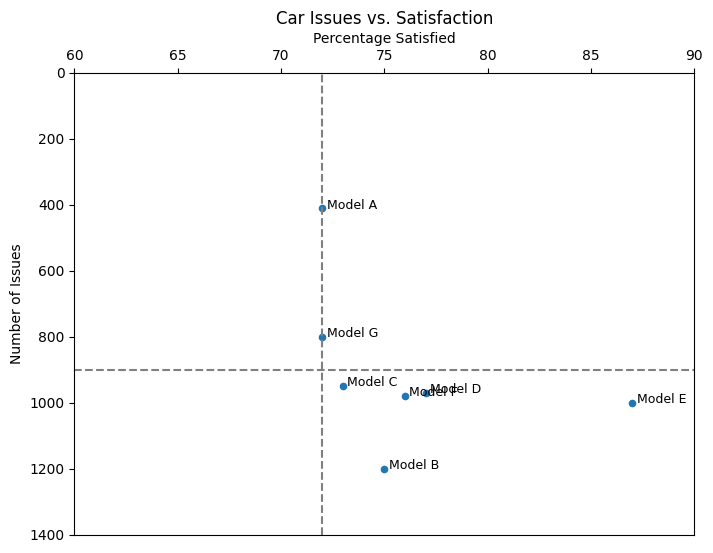

In [62]:
# Plot
ax = df_car.plot.scatter(x='percentage_satisfied', y='car_issues', figsize=(8, 6))
plt.title('Car Issues vs. Satisfaction')
# X-axis at top
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

# Get means
mean_x = df_car['percentage_satisfied'].mean()
mean_y = df_car['car_issues'].mean()

# Draw dividing lines at x=75, y=900
ax.axhline(y=900, color='gray', linestyle='--')
ax.axvline(x=72, color='gray', linestyle='--')

ax.invert_yaxis()                     # Flip the y-axis
ax.set_yticks(range(0, 1401, 200))    # Set ticks from 0 to 1400 with step 200

plt.xlabel('Percentage Satisfied')
plt.ylabel('Number of Issues')
plt.xlim(60,90)
#plt.ylim(0,1400)
plt.grid(False)  # Turn off grid

# Add labels (car model) to each point
for i, row in df_car.iterrows():
    plt.text(row['percentage_satisfied'] + 0.2, row['car_issues'], row['car_model'], fontsize=9)

plt.show()

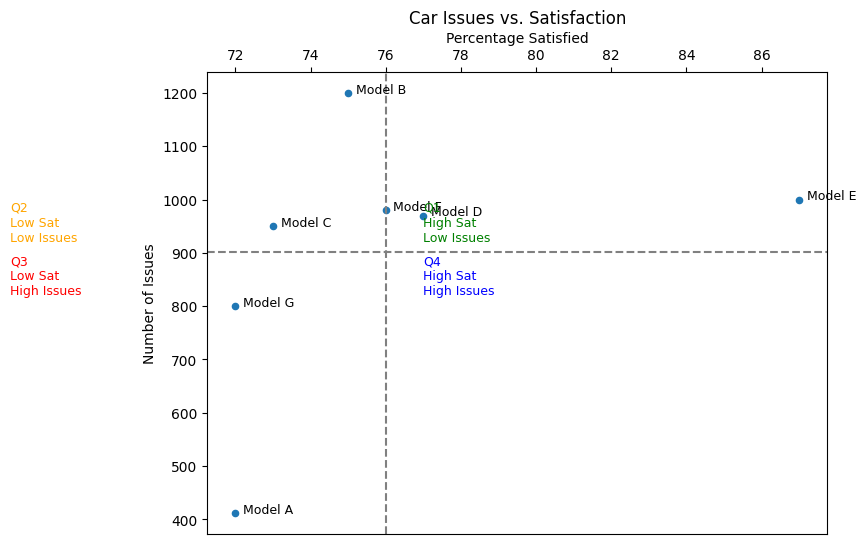

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
df_car = pd.DataFrame({
    "car_model": ['Model A', 'Model B', 'Model C', 'Model D', 'Model E', 'Model F', 'Model G'],
    "car_issues": ['412', '1200', '950', '970', '1000', '980', '800'],
    "percentage_satisfied": ['72', '75', '73', '77', '87', '76', '72']
})

# Convert to numeric
df_car['car_issues'] = df_car['car_issues'].astype(int)
df_car['percentage_satisfied'] = df_car['percentage_satisfied'].astype(int)

# Get means
mean_x = df_car['percentage_satisfied'].mean()
mean_y = df_car['car_issues'].mean()

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
df_car.plot.scatter(x='percentage_satisfied', y='car_issues', ax=ax)

# Move x-axis to top
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xlabel('Percentage Satisfied')
plt.ylabel('Number of Issues')
plt.title('Car Issues vs. Satisfaction')

# No grid
plt.grid(False)

# Add quadrant lines
ax.axhline(mean_y, color='gray', linestyle='--')
ax.axvline(mean_x, color='gray', linestyle='--')

# Label each point
for i, row in df_car.iterrows():
    plt.text(row['percentage_satisfied'] + 0.2, row['car_issues'], row['car_model'], fontsize=9)

# Optional: Add quadrant labels
plt.text(mean_x + 1, mean_y + 20, "Q1\nHigh Sat\nLow Issues", fontsize=9, color='green')
plt.text(mean_x - 10, mean_y + 20, "Q2\nLow Sat\nLow Issues", fontsize=9, color='orange')
plt.text(mean_x - 10, mean_y - 80, "Q3\nLow Sat\nHigh Issues", fontsize=9, color='red')
plt.text(mean_x + 1, mean_y - 80, "Q4\nHigh Sat\nHigh Issues", fontsize=9, color='blue')

plt.show()
